<a href="https://colab.research.google.com/github/NamishBansal15/substation-detection/blob/main/yolo_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow ultralytics wandb -q

import wandb
import os
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

# ── Dataset ─────────────────────────────────────────────────────
rf = Roboflow(api_key="ksuJELafzWtoYO925LkP")
project = rf.workspace("space-weather").project("merged-dataset-gzbkg")
dataset = project.version(2).download("yolov8")
DATA_YAML = f"{dataset.location}/data.yaml"
print(f"Dataset ready at: {DATA_YAML}")

# ── Drive mount for checkpoints ─────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR = "/content/drive/MyDrive/april-detection/yolo"
os.makedirs(DRIVE_DIR, exist_ok=True)

import os
import shutil
import random
from pathlib import Path
from collections import defaultdict

import os
import shutil
import random
from pathlib import Path

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 82.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to merged-dataset-2 in yolov8:: 100%|██████████| 2781/2781 [00:00<00:00, 8822.55it/s]


Dataset ready at: /content/merged-dataset-2/data.yaml
Mounted at /content/drive


In [ ]:
!pip install wandb roboflow ultralytics -q

import os, shutil, threading, time
from pathlib import Path
from datetime import datetime

import torch
import pandas as pd
from ultralytics import YOLO
import wandb
from roboflow import Roboflow
from google.colab import drive

drive.mount('/content/drive')

# ════════════════════════════════════════════════════════════════
# CONFIG
# ════════════════════════════════════════════════════════════════
ROBOFLOW_API_KEY = "YOUR_NEW_API_KEY"
WANDB_PROJECT    = "april-detection-ablation"
RESULTS_FILE     = "/content/drive/MyDrive/april-detection/ablation_results.json"
DRIVE_DIR        = "/content/drive/MyDrive/april-detection/ablation_yolo"

DATASET_TIERS = {
    "augmented": {
        "workspace": "coriell",
        "train":     ("augmented-train-only", 2),
        "valid":     ("augmented-valid",      2),
        "test":      ("augmented-test",       3),
    },
}

CLASSES     = ["Alt Energy", "Circuit Breaker", "Control", "Power Lines", "Reactor", "Transformer"]
NUM_CLASSES = 6
BATCH_SIZES = {"yolov8n": 32, "yolov8s": 16, "yolov8m": 8}

# ════════════════════════════════════════════════════════════════
# HEARTBEAT
# ════════════════════════════════════════════════════════════════
def start_heartbeat():
    def _beat():
        while True:
            print(f"[Heartbeat] {time.strftime('%H:%M:%S')}")
            time.sleep(120)
    threading.Thread(target=_beat, daemon=True).start()

start_heartbeat()

# ════════════════════════════════════════════════════════════════
# DOWNLOAD
# ════════════════════════════════════════════════════════════════
def download_tier(tier_name, tier_cfg):
    rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
    out_dir = f"/content/datasets/{tier_name}"
    os.makedirs(out_dir, exist_ok=True)

    for split in ["train", "valid", "test"]:
        slug, version = tier_cfg[split]
        ds  = rf.workspace(tier_cfg["workspace"]).project(slug).version(version).download("yolov8")
        src = Path(ds.location) / split

        img_dst = Path(out_dir) / split / "images"
        lbl_dst = Path(out_dir) / split / "labels"
        img_dst.mkdir(parents=True, exist_ok=True)
        lbl_dst.mkdir(parents=True, exist_ok=True)

        for f in (src / "images").iterdir():
            if f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                shutil.copy2(str(f), str(img_dst / f.name))

        for f in (src / "labels").iterdir():
            if f.suffix == ".txt":
                shutil.copy2(str(f), str(lbl_dst / f.name))

        print(f"  [{tier_name}/{split}] "
              f"{len(list(img_dst.glob('*.jpg')))} images, "
              f"{len(list(lbl_dst.glob('*.txt')))} labels")

    with open(f"{out_dir}/data.yaml", "w") as f:
        f.write(f"path: {out_dir}\n"
                f"train: train/images\n"
                f"val: valid/images\n"
                f"test: test/images\n"
                f"nc: {NUM_CLASSES}\n"
                f"names: {CLASSES}\n")

    print(f"✅ Tier '{tier_name}' ready at {out_dir}")
    return out_dir

# ════════════════════════════════════════════════════════════════
# VALIDATE
# ════════════════════════════════════════════════════════════════
def validate_tier(tier_name, data_dir):
    print(f"\n🔍 Validating {tier_name}")
    all_good = True

    for split in ["train", "valid", "test"]:
        img_dir = Path(data_dir) / split / "images"
        lbl_dir = Path(data_dir) / split / "labels"
        n_imgs   = len(list(img_dir.glob("*.jpg"))) + len(list(img_dir.glob("*.png")))
        n_labels = len(list(lbl_dir.glob("*.txt")))
        print(f"  {split}: {n_imgs} images, {n_labels} labels")
        if n_imgs == 0:
            print(f"    ❌ NO IMAGES"); all_good = False
        if n_labels == 0:
            print(f"    ❌ NO LABELS"); all_good = False
        if n_imgs > 0 and abs(n_imgs - n_labels) > n_imgs * 0.05:
            print(f"    ⚠️ image/label count mismatch (>5%)")

    # Check class IDs in a sample of label files
    import random
    labels = list((Path(data_dir) / "train" / "labels").glob("*.txt"))
    sample = random.sample(labels, min(20, len(labels)))
    class_ids = set()
    for lbl in sample:
        with open(lbl) as f:
            for line in f:
                if line.strip():
                    class_ids.add(int(line.split()[0]))
    print(f"  Class IDs in train sample: {sorted(class_ids)} (expected 0-{NUM_CLASSES-1})")
    if max(class_ids) >= NUM_CLASSES:
        print(f"    ❌ CLASS ID OUT OF RANGE"); all_good = False

    if all_good:
        print(f"  ✅ {tier_name} looks good — safe to train")
    else:
        print(f"  🛑 {tier_name} has issues — DO NOT TRAIN")
    return all_good

# ════════════════════════════════════════════════════════════════
# UTILITIES
# ════════════════════════════════════════════════════════════════
def save_metrics(metrics):
    import json
    results = []
    if os.path.exists(RESULTS_FILE):
        with open(RESULTS_FILE) as f:
            results = json.load(f)
    metrics["timestamp"] = datetime.now().isoformat()
    results.append(metrics)
    os.makedirs(Path(RESULTS_FILE).parent, exist_ok=True)
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"[Metrics] Saved → {metrics['model_name']}")

def sync_checkpoints(src, dst, stop_event):
    os.makedirs(dst, exist_ok=True)
    while not stop_event.is_set():
        try:
            for f in Path(src).rglob("*.pt"):
                d = Path(dst) / f.name
                if not d.exists():
                    shutil.copy2(str(f), str(d))
                    print(f"[Sync] {f.name}")
        except Exception as e:
            print(f"[Sync] Error: {e}")
        time.sleep(300)

# ════════════════════════════════════════════════════════════════
# YOLO
# ════════════════════════════════════════════════════════════════
def train_yolo(model_name, tier_name, data_dir):
    run_name  = f"{model_name}-{tier_name}"
    drive_dir = f"{DRIVE_DIR}/{run_name}"

    print(f"\n🚀 Training {run_name}")

    wandb.init(project=WANDB_PROJECT, name=run_name,
               config={"tier": tier_name, "model": model_name, "epochs": 50},
               reinit=True)

    stop_event  = threading.Event()
    sync_thread = threading.Thread(
        target=sync_checkpoints,
        args=(f"/content/runs/detect/{run_name}/weights", drive_dir, stop_event),
        daemon=True)
    sync_thread.start()

    model = YOLO(f"{model_name}.pt")
    model.train(
        data=f"{data_dir}/data.yaml",
        epochs=50,
        imgsz=640,
        batch=BATCH_SIZES[model_name],
        name=run_name,
        exist_ok=True,
        plots=True,
    )

    stop_event.set()

    # ── Per-epoch metrics from results.csv ───────────────────────
    results_path = f"/content/runs/detect/{run_name}/results.csv"
    if os.path.exists(results_path):
        df = pd.read_csv(results_path)
        df.columns = df.columns.str.strip()
        for _, row in df.iterrows():
            wandb.log({
                "epoch":        int(row["epoch"]),
                "mAP50":        float(row["metrics/mAP50(B)"]),
                "mAP50_95":     float(row["metrics/mAP50-95(B)"]),
                "precision":    float(row["metrics/precision(B)"]),
                "recall":       float(row["metrics/recall(B)"]),
                "box_loss":     float(row["train/box_loss"]),
                "cls_loss":     float(row["train/cls_loss"]),
                "dfl_loss":     float(row["train/dfl_loss"]),
                "val_box_loss": float(row["val/box_loss"]),
                "val_cls_loss": float(row["val/cls_loss"]),
            })
        best = df.loc[df["metrics/mAP50(B)"].idxmax()]
        print(f"  Best mAP50={best['metrics/mAP50(B)']:.4f} at epoch {int(best['epoch'])}")
    else:
        print(f"  ⚠️ results.csv not found")

    # ── Per-class metrics from best weights ──────────────────────
    weights = f"/content/runs/detect/{run_name}/weights/best.pt"
    if os.path.exists(weights):
        val = YOLO(weights).val(data=f"{data_dir}/data.yaml", verbose=False)

        per_class_metrics = {}
        for i, cls in enumerate(CLASSES):
            try:
                per_class_metrics[f"ap50_{cls.lower().replace(' ','_')}"]    = float(val.box.ap50[i])
                per_class_metrics[f"ap50_95_{cls.lower().replace(' ','_')}"] = float(val.box.ap[i])
            except IndexError:
                pass

        save_metrics({
            "model_name":   run_name,
            "tier":         tier_name,
            "architecture": model_name,
            "mAP50":        round(float(val.box.map50), 4),
            "mAP50_95":     round(float(val.box.map),   4),
            "precision":    round(float(val.box.mp),     4),
            "recall":       round(float(val.box.mr),     4),
            "inference_ms": float(val.speed["inference"]),
            "model_size_mb": round(os.path.getsize(weights) / 1e6, 2),
            "per_class":    {k: v for k, v in per_class_metrics.items()
                             if k.startswith("ap50_") and not k.startswith("ap50_95")},
        })

        wandb.log({
            "final_mAP50":     val.box.map50,
            "final_mAP50_95":  val.box.map,
            "final_precision": val.box.mp,
            "final_recall":    val.box.mr,
            "inference_ms":    val.speed["inference"],
            "model_size_mb":   round(os.path.getsize(weights) / 1e6, 2),
            **per_class_metrics
        })

        os.makedirs(drive_dir, exist_ok=True)
        shutil.copy2(weights, f"{drive_dir}/best.pt")
        print(f"  ✅ Best weights saved to Drive")
        print(f"  Inference: {val.speed['inference']:.1f}ms")
    else:
        print(f"  ⚠️ No weights found")

    wandb.finish()
    print(f"✅ Done: {run_name}")

# ════════════════════════════════════════════════════════════════
# MAIN
# ════════════════════════════════════════════════════════════════
wandb.login()
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

for tier_name, tier_cfg in DATASET_TIERS.items():
    print(f"\n{'='*60}\nTIER: {tier_name}\n{'='*60}")

    data_dir = download_tier(tier_name, tier_cfg)

    if not validate_tier(tier_name, data_dir):
        print(f"⛔ Skipping {tier_name} — fix dataset first")
        continue

    train_yolo("yolov8n", tier_name, data_dir)
    train_yolo("yolov8s", tier_name, data_dir)
    train_yolo("yolov8m", tier_name, data_dir)

print("\n🎉 Ablation complete!")

loading Roboflow workspace...
loading Roboflow project...
Dataset ready at: /content/merged-dataset-2/data.yaml


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Splitting dataset 70/20/10...
Total: 1389 → Train: 972, Val: 277, Test: 140
✅ Split complete!

Starting: yolov8s


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged-dataset-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ap50_95_alt_energy,▁
ap50_95_circuit_breaker,▁
ap50_95_control,▁
ap50_95_power_lines,▁
ap50_95_reactor,▁
ap50_95_transformer,▁
ap50_alt_energy,▁
ap50_circuit_breaker,▁
ap50_control,▁
ap50_power_lines,▁
+18,...


...

ap50_95_alt_energy,▁
ap50_95_circuit_breaker,▁
ap50_95_control,▁
ap50_95_power_lines,▁
ap50_95_reactor,▁
ap50_95_transformer,▁
ap50_alt_energy,▁
ap50_circuit_breaker,▁
ap50_control,▁
ap50_power_lines,▁
+18,...


✅ Finished: yolo12m

Starting: yolo12l


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged-dataset-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo12l, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, persp

ap50_95_alt_energy,▁
ap50_95_circuit_breaker,▁
ap50_95_control,▁
ap50_95_power_lines,▁
ap50_95_reactor,▁
ap50_95_transformer,▁
ap50_alt_energy,▁
ap50_circuit_breaker,▁
ap50_control,▁
ap50_power_lines,▁
+18,...


✅ Finished: yolo12l

🎉 All runs complete!


In [ ]:


def split_dataset(dataset_location, train_ratio=0.7, val_ratio=0.2, test_ratio=0.1, seed=42):
    random.seed(seed)

    src_images = Path(dataset_location) / "train" / "images"
    src_labels = Path(dataset_location) / "train" / "labels"

    for split in ["valid", "test"]:
        (Path(dataset_location) / split / "images").mkdir(parents=True, exist_ok=True)
        (Path(dataset_location) / split / "labels").mkdir(parents=True, exist_ok=True)

    all_images = list(src_images.glob("*.*"))
    random.shuffle(all_images)

    n = len(all_images)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    val_files  = all_images[n_train:n_train + n_val]
    test_files = all_images[n_train + n_val:]

    print(f"Total: {n} → Train: {n_train}, Val: {len(val_files)}, Test: {len(test_files)}")

    val_set  = set(val_files)
    test_set = set(test_files)

    for img_path in val_set | test_set:
        split = "valid" if img_path in val_set else "test"
        label_path = src_labels / (img_path.stem + ".txt")
        shutil.move(str(img_path), Path(dataset_location) / split / "images" / img_path.name)
        if label_path.exists():
            shutil.move(str(label_path), Path(dataset_location) / split / "labels" / label_path.name)

    print("✅ Split complete!")

print("Splitting dataset 70/20/10...")
split_dataset(dataset.location)

DATA_YAML = f"{dataset.location}/data.yaml"

# ── Config ──────────────────────────────────────────────────────
WANDB_PROJECT = "april-detection"
CLASSES = ["Alt Energy", "Circuit Breaker", "Control", "Power Lines", "Reactor", "Transformer"]

configs = [
    {"name": "yolov8n",  "model": "yolov8n.pt",  "epochs": 50, "imgsz": 640, "batch": 32},
    {"name": "yolo11n",  "model": "yolo11n.pt",  "epochs": 50, "imgsz": 640, "batch": 32},
    {"name": "yolo12n",  "model": "yolo12n.pt",  "epochs": 50, "imgsz": 640, "batch": 32},
]

# ── Checkpoint sync ──────────────────────────────────────────────
import shutil, threading, time

def sync_checkpoints(model_name, stop_event):
    src = f"/content/runs/detect/{model_name}/weights"
    dst = f"{DRIVE_DIR}/{model_name}/weights"
    os.makedirs(dst, exist_ok=True)
    while not stop_event.is_set():
        try:
            if os.path.exists(src):
                for f in os.listdir(src):
                    s = f"{src}/{f}"
                    d = f"{dst}/{f}"
                    if not os.path.exists(d):
                        shutil.copy2(s, d)
                        print(f"[Sync] Saved {model_name}/{f} to Drive")
        except Exception as e:
            print(f"[Sync] Error: {e}")
        time.sleep(300)

# ── Training loop ────────────────────────────────────────────────
wandb.login()

for cfg in configs:
    print(f"\n{'='*50}")
    print(f"Starting: {cfg['name']}")
    print(f"{'='*50}")

    wandb.init(
        project=WANDB_PROJECT,
        name=cfg["name"],
        config=cfg,
        reinit=True
    )

    # Start checkpoint sync
    stop_event = threading.Event()
    sync_thread = threading.Thread(
        target=sync_checkpoints,
        args=(cfg["name"], stop_event),
        daemon=True
    )
    sync_thread.start()

    model = YOLO(cfg["model"])

    model.train(
        data=DATA_YAML,
        epochs=cfg["epochs"],
        imgsz=cfg["imgsz"],
        batch=cfg["batch"],
        name=cfg["name"],
        exist_ok=True,
        plots=True,
    )

    # Stop sync
    stop_event.set()

    # ── Per-epoch metrics from results.csv ───────────────────────
    results_path = f"/content/runs/detect/{cfg['name']}/results.csv"
    if os.path.exists(results_path):
        df = pd.read_csv(results_path)
        df.columns = df.columns.str.strip()

        for _, row in df.iterrows():
            wandb.log({
                "epoch":        int(row["epoch"]),
                "mAP50":        float(row["metrics/mAP50(B)"]),
                "mAP50_95":     float(row["metrics/mAP50-95(B)"]),
                "precision":    float(row["metrics/precision(B)"]),
                "recall":       float(row["metrics/recall(B)"]),
                "box_loss":     float(row["train/box_loss"]),
                "cls_loss":     float(row["train/cls_loss"]),
                "dfl_loss":     float(row["train/dfl_loss"]),
                "val_box_loss": float(row["val/box_loss"]),
                "val_cls_loss": float(row["val/cls_loss"]),
            })

        best = df.loc[df["metrics/mAP50(B)"].idxmax()]
        print(f"  Best mAP50={best['metrics/mAP50(B)']:.4f} at epoch {int(best['epoch'])}")
    else:
        print(f"  ⚠️ results.csv not found")

    # ── Per-class metrics from best weights ──────────────────────
    weights = f"/content/runs/detect/{cfg['name']}/weights/best.pt"
    if os.path.exists(weights):
        val_model = YOLO(weights)
        val = val_model.val(data=DATA_YAML, verbose=False)

        per_class_metrics = {}
        for i, cls in enumerate(CLASSES):
            try:
                per_class_metrics[f"ap50_{cls.lower().replace(' ', '_')}"]    = float(val.box.ap50[i])
                per_class_metrics[f"ap50_95_{cls.lower().replace(' ', '_')}"] = float(val.box.ap[i])
            except IndexError:
                pass

        wandb.log({
            "final_mAP50":     float(val.box.map50),
            "final_mAP50_95":  float(val.box.map),
            "final_precision": float(val.box.mp),
            "final_recall":    float(val.box.mr),
            "inference_ms":    float(val.speed["inference"]),
            "model_size_mb":   round(os.path.getsize(weights) / 1e6, 2),
            **per_class_metrics
        })

        # Copy final weights to Drive
        dst_weights = f"{DRIVE_DIR}/{cfg['name']}/weights"
        os.makedirs(dst_weights, exist_ok=True)
        shutil.copy2(weights, f"{dst_weights}/best.pt")
        print(f"  ✅ Best weights saved to Drive")
        print(f"  Inference: {val.speed['inference']:.1f}ms")
    else:
        print(f"  ⚠️ No weights found")

    wandb.finish()
    print(f"✅ Finished: {cfg['name']}")

print("\n🎉 All runs complete!")

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


Splitting dataset 70/20/10...
Total: 1389 → Train: 972, Val: 277, Test: 140
✅ Split complete!

Starting: yolov8n


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged-dataset-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ap50_95_alt_energy,▁
ap50_95_circuit_breaker,▁
ap50_95_control,▁
ap50_95_power_lines,▁
ap50_95_reactor,▁
ap50_95_transformer,▁
ap50_alt_energy,▁
ap50_circuit_breaker,▁
ap50_control,▁
ap50_power_lines,▁
+18,...


...

ap50_95_alt_energy,▁
ap50_95_circuit_breaker,▁
ap50_95_control,▁
ap50_95_power_lines,▁
ap50_95_reactor,▁
ap50_95_transformer,▁
ap50_alt_energy,▁
ap50_circuit_breaker,▁
ap50_control,▁
ap50_power_lines,▁
+18,...


✅ Finished: yolo11n

Starting: yolo12n


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/merged-dataset-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo12n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

ap50_95_alt_energy,▁
ap50_95_circuit_breaker,▁
ap50_95_control,▁
ap50_95_power_lines,▁
ap50_95_reactor,▁
ap50_95_transformer,▁
ap50_alt_energy,▁
ap50_circuit_breaker,▁
ap50_control,▁
ap50_power_lines,▁
+18,...


✅ Finished: yolo12n

🎉 All runs complete!


In [ ]:
for split in ["valid", "test"]:
    for img in Path(f"/content/merged-dataset-2/{split}/images").glob("*.*"):
        shutil.move(str(img), f"/content/merged-dataset-2/train/images/{img.name}")
    for lbl in Path(f"/content/merged-dataset-2/{split}/labels").glob("*.txt"):
        shutil.move(str(lbl), f"/content/merged-dataset-2/train/labels/{lbl.name}")

print("Restored!")
print(f"Train: {len(list(Path('/content/merged-dataset-2/train/images').glob('*.*')))}")

Restored!
Train: 1389


In [ ]:
import wandb

api = wandb.Api()
runs = api.runs("namishemail-george-mason-university/april-detection")

for run in runs:
    print(f"\n{run.name} — {run.state}")
    hist = run.history(samples=5)
    print(hist.columns.tolist())


yolov8s — finished
[]

yolov8s — finished
[]

yolov8s — finished
[]

yolov8s — finished
[]

yolov8s — finished
['box_loss', '_step', 'cls_loss', 'val_cls_loss', '_runtime', 'val_box_loss', 'epoch', 'precision', 'mAP50', 'dfl_loss', 'recall', '_timestamp', 'mAP50_95']

yolov8m — finished
['box_loss', '_step', 'cls_loss', 'val_cls_loss', '_runtime', 'val_box_loss', 'epoch', 'precision', 'mAP50', 'dfl_loss', 'recall', '_timestamp', 'mAP50_95']

yolov8l — finished
['box_loss', '_step', 'cls_loss', 'val_cls_loss', '_runtime', 'val_box_loss', 'epoch', 'precision', 'mAP50', 'dfl_loss', 'recall', '_timestamp', 'mAP50_95']

yolo11s — finished
['box_loss', '_step', 'cls_loss', 'val_cls_loss', '_runtime', 'val_box_loss', 'epoch', 'precision', 'mAP50', 'dfl_loss', 'recall', '_timestamp', 'mAP50_95']

yolo11m — finished
['box_loss', '_step', 'cls_loss', 'val_cls_loss', '_runtime', 'val_box_loss', 'epoch', 'precision', 'mAP50', 'dfl_loss', 'recall', '_timestamp', 'mAP50_95']

yolo11l — finished
['b

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 63.8 MB/s eta 0:00:00


In [ ]:
import wandb
from ultralytics import YOLO

api = wandb.Api()
CLASSES = ["Alt Energy", "Circuit Breaker", "Control", "Power Lines", "Reactor", "Transformer"]
DRIVE_DIR = "/content/drive/MyDrive/april-detection/yolo"

models_to_eval = ["yolov8s", "yolov8m", "yolov8l", "yolo11s", "yolo11m", "yolo11l", "yolo12s", "yolo12m"]

for model_name in models_to_eval:
    weights = f"{DRIVE_DIR}/{model_name}/weights/best.pt"
    if not os.path.exists(weights):
        print(f"⚠️ No weights found for {model_name}")
        continue

    # Resume the wandb run
    runs = api.runs(f"namishemail-george-mason-university/april-detection")
    run_id = next((r.id for r in runs if r.name == model_name), None)
    if not run_id:
        print(f"⚠️ No wandb run found for {model_name}")
        continue

    wandb.init(project="april-detection", name=model_name, id=run_id, resume="must")

    val_model = YOLO(weights)
    val = val_model.val(data=DATA_YAML, verbose=False)

    per_class_metrics = {}
    for i, cls in enumerate(CLASSES):
        try:
            per_class_metrics[f"ap50_{cls.lower().replace(' ', '_')}"]    = float(val.box.ap50[i])
            per_class_metrics[f"ap50_95_{cls.lower().replace(' ', '_')}"] = float(val.box.ap[i])
        except IndexError:
            pass

    wandb.log({
        "final_mAP50":     float(val.box.map50),
        "final_mAP50_95":  float(val.box.map),
        "final_precision": float(val.box.mp),
        "final_recall":    float(val.box.mr),
        "inference_ms":    float(val.speed["inference"]),
        "model_size_mb":   round(os.path.getsize(weights) / 1e6, 2),
        **per_class_metrics
    })

    wandb.finish()
    print(f"✅ {model_name} per-class metrics logged")

wandb: Currently logged in as: namishemail (namishemail-george-mason-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs



FileNotFoundError: Dataset '/content/merged-dataset-2/data.yaml' images not found, missing path '/content/merged-dataset-2/valid/images'
Note dataset download directory is '/content/datasets'. You can update this in '/root/.config/Ultralytics/settings.json'

     model  final_mAP50  final_mAP50_95  inference_ms  model_size_mb
0  yolov8s       0.6404          0.3486         10.74          22.52
1  yolo11s       0.6315          0.3472         11.09          19.18
2  yolov8m       0.6021          0.3329         26.64          52.04
3  yolo12s       0.5991          0.3203         15.83          18.94
4  yolo11m       0.5652          0.2880         33.49          40.52
5  yolov8l       0.5297          0.2822         49.48          87.65
6  yolo11l       0.5207          0.2575         42.96          51.20
7  yolo12m       0.5099          0.2584         41.18          40.77
8  yolo12l       0.4906          0.2476         65.41          53.53


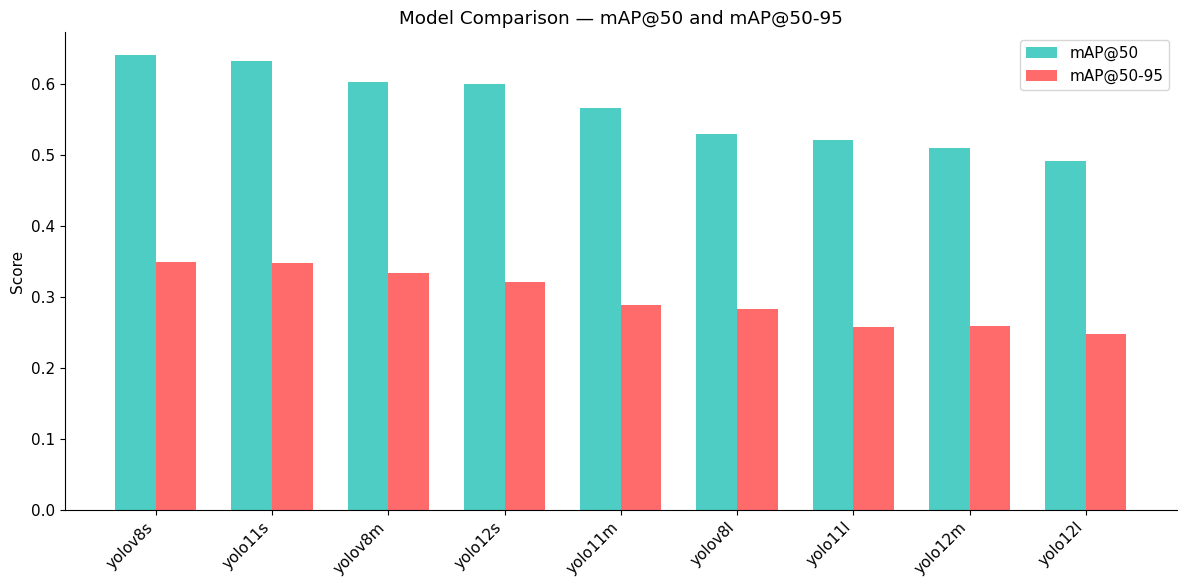

Saved: model_comparison.png


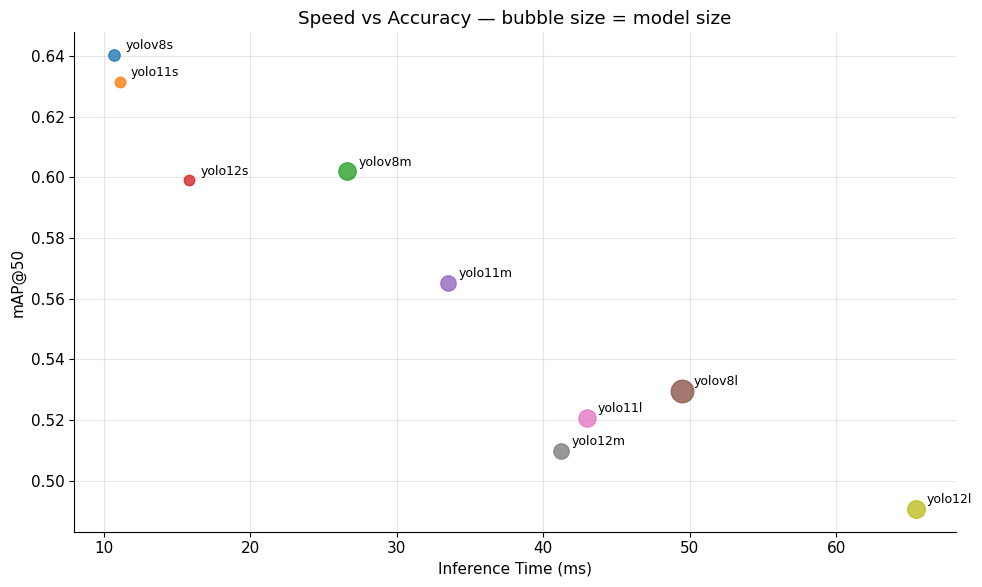

Saved: speed_vs_accuracy.png


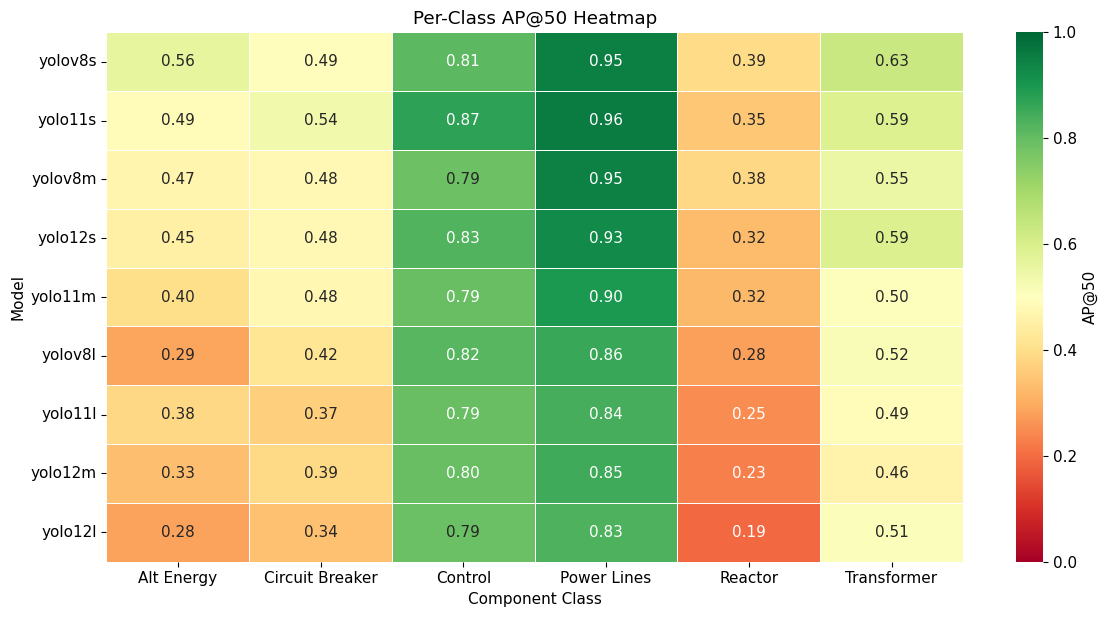

Saved: perclass_heatmap.png


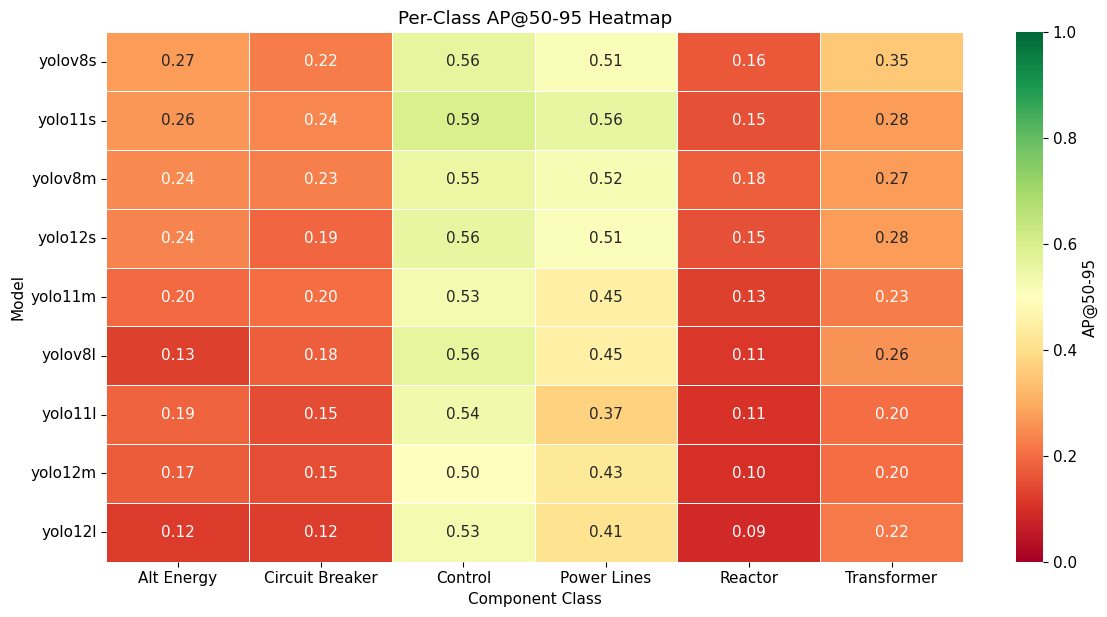

Saved: perclass_heatmap_95.png


ValueError: Could not find project april-detection

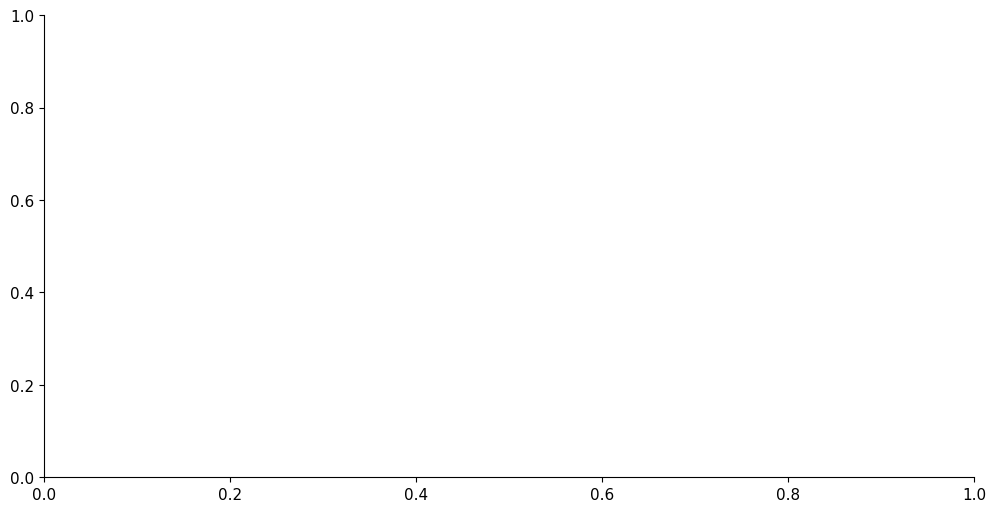

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Paste your manual_results dict here ────────────────────────
manual_results = [
    {
        "model": "yolov8s",
        "final_mAP50": 0.6404, "final_mAP50_95": 0.3486,
        "precision": 0.6751, "recall": 0.6046,
        "inference_ms": 10.74, "model_size_mb": 22.52,
        "ap50_alt_energy": 0.5614, "ap50_circuit_breaker": 0.4935,
        "ap50_control": 0.8117, "ap50_power_lines": 0.9498,
        "ap50_reactor": 0.3934, "ap50_transformer": 0.6325,
        "ap50_95_alt_energy": 0.2744, "ap50_95_circuit_breaker": 0.2248,
        "ap50_95_control": 0.5622, "ap50_95_power_lines": 0.5124,
        "ap50_95_reactor": 0.1646, "ap50_95_transformer": 0.3533,
    },
    {
        "model": "yolov8m",
        "final_mAP50": 0.6021, "final_mAP50_95": 0.3329,
        "precision": 0.6374, "recall": 0.5740,
        "inference_ms": 26.64, "model_size_mb": 52.04,
        "ap50_alt_energy": 0.4660, "ap50_circuit_breaker": 0.4779,
        "ap50_control": 0.7866, "ap50_power_lines": 0.9479,
        "ap50_reactor": 0.3837, "ap50_transformer": 0.5505,
        "ap50_95_alt_energy": 0.2448, "ap50_95_circuit_breaker": 0.2280,
        "ap50_95_control": 0.5515, "ap50_95_power_lines": 0.5229,
        "ap50_95_reactor": 0.1759, "ap50_95_transformer": 0.2745,
    },
    {
        "model": "yolov8l",
        "final_mAP50": 0.5297, "final_mAP50_95": 0.2822,
        "precision": 0.5269, "recall": 0.5308,
        "inference_ms": 49.48, "model_size_mb": 87.65,
        "ap50_alt_energy": 0.2885, "ap50_circuit_breaker": 0.4183,
        "ap50_control": 0.8175, "ap50_power_lines": 0.8578,
        "ap50_reactor": 0.2791, "ap50_transformer": 0.5172,
        "ap50_95_alt_energy": 0.1267, "ap50_95_circuit_breaker": 0.1793,
        "ap50_95_control": 0.5621, "ap50_95_power_lines": 0.4529,
        "ap50_95_reactor": 0.1122, "ap50_95_transformer": 0.2600,
    },
    {
        "model": "yolo11s",
        "final_mAP50": 0.6315, "final_mAP50_95": 0.3472,
        "precision": 0.6476, "recall": 0.6046,
        "inference_ms": 11.09, "model_size_mb": 19.18,
        "ap50_alt_energy": 0.4860, "ap50_circuit_breaker": 0.5378,
        "ap50_control": 0.8718, "ap50_power_lines": 0.9576,
        "ap50_reactor": 0.3487, "ap50_transformer": 0.5868,
        "ap50_95_alt_energy": 0.2641, "ap50_95_circuit_breaker": 0.2388,
        "ap50_95_control": 0.5943, "ap50_95_power_lines": 0.5569,
        "ap50_95_reactor": 0.1539, "ap50_95_transformer": 0.2751,
    },
    {
        "model": "yolo11m",
        "final_mAP50": 0.5652, "final_mAP50_95": 0.2880,
        "precision": 0.6411, "recall": 0.5149,
        "inference_ms": 33.49, "model_size_mb": 40.52,
        "ap50_alt_energy": 0.4013, "ap50_circuit_breaker": 0.4752,
        "ap50_control": 0.7935, "ap50_power_lines": 0.8969,
        "ap50_reactor": 0.3205, "ap50_transformer": 0.5040,
        "ap50_95_alt_energy": 0.1950, "ap50_95_circuit_breaker": 0.2016,
        "ap50_95_control": 0.5275, "ap50_95_power_lines": 0.4524,
        "ap50_95_reactor": 0.1267, "ap50_95_transformer": 0.2250,
    },
    {
        "model": "yolo11l",
        "final_mAP50": 0.5207, "final_mAP50_95": 0.2575,
        "precision": 0.5301, "recall": 0.5123,
        "inference_ms": 42.96, "model_size_mb": 51.20,
        "ap50_alt_energy": 0.3832, "ap50_circuit_breaker": 0.3679,
        "ap50_control": 0.7943, "ap50_power_lines": 0.8419,
        "ap50_reactor": 0.2473, "ap50_transformer": 0.4895,
        "ap50_95_alt_energy": 0.1856, "ap50_95_circuit_breaker": 0.1455,
        "ap50_95_control": 0.5353, "ap50_95_power_lines": 0.3717,
        "ap50_95_reactor": 0.1051, "ap50_95_transformer": 0.2017,
    },
    {
        "model": "yolo12s",
        "final_mAP50": 0.5991, "final_mAP50_95": 0.3203,
        "precision": 0.6280, "recall": 0.5607,
        "inference_ms": 15.83, "model_size_mb": 18.94,
        "ap50_alt_energy": 0.4509, "ap50_circuit_breaker": 0.4766,
        "ap50_control": 0.8256, "ap50_power_lines": 0.9268,
        "ap50_reactor": 0.3243, "ap50_transformer": 0.5901,
        "ap50_95_alt_energy": 0.2356, "ap50_95_circuit_breaker": 0.1887,
        "ap50_95_control": 0.5566, "ap50_95_power_lines": 0.5112,
        "ap50_95_reactor": 0.1528, "ap50_95_transformer": 0.2766,
    },
    {
        "model": "yolo12m",
        "final_mAP50": 0.5099, "final_mAP50_95": 0.2584,
        "precision": 0.5020, "recall": 0.5202,
        "inference_ms": 41.18, "model_size_mb": 40.77,
        "ap50_alt_energy": 0.3324, "ap50_circuit_breaker": 0.3888,
        "ap50_control": 0.7961, "ap50_power_lines": 0.8484,
        "ap50_reactor": 0.2298, "ap50_transformer": 0.4641,
        "ap50_95_alt_energy": 0.1726, "ap50_95_circuit_breaker": 0.1491,
        "ap50_95_control": 0.5003, "ap50_95_power_lines": 0.4271,
        "ap50_95_reactor": 0.0993, "ap50_95_transformer": 0.2021,
    },
    {
        "model": "yolo12l",
        "final_mAP50": 0.4906, "final_mAP50_95": 0.2476,
        "precision": 0.4669, "recall": 0.5023,
        "inference_ms": 65.41, "model_size_mb": 53.53,
        "ap50_alt_energy": 0.2817, "ap50_circuit_breaker": 0.3365,
        "ap50_control": 0.7907, "ap50_power_lines": 0.8308,
        "ap50_reactor": 0.1943, "ap50_transformer": 0.5099,
        "ap50_95_alt_energy": 0.1174, "ap50_95_circuit_breaker": 0.1217,
        "ap50_95_control": 0.5281, "ap50_95_power_lines": 0.4134,
        "ap50_95_reactor": 0.0861, "ap50_95_transformer": 0.2189,
    },
]

# ── Setup ───────────────────────────────────────────────────────
df = pd.DataFrame(manual_results)
df = df.sort_values("final_mAP50", ascending=False).reset_index(drop=True)

CLASSES = ["Alt Energy", "Circuit Breaker", "Control", "Power Lines", "Reactor", "Transformer"]

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = plt.cm.tab10.colors

print(df[["model", "final_mAP50", "final_mAP50_95", "inference_ms", "model_size_mb"]].to_string())

# ── 1. Model comparison bar chart ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df))
w = 0.35
ax.bar(x - w/2, df["final_mAP50"],    w, label="mAP@50",    color="#4ECDC4")
ax.bar(x + w/2, df["final_mAP50_95"], w, label="mAP@50-95", color="#FF6B6B")
ax.set_xticks(x)
ax.set_xticklabels(df["model"], rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model Comparison — mAP@50 and mAP@50-95")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: model_comparison.png")

# ── 2. Speed vs accuracy scatter ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for i, (_, row) in enumerate(df.iterrows()):
    ax.scatter(row["inference_ms"], row["final_mAP50"],
               s=row["model_size_mb"] * 3,  # bubble size = model size
               color=COLORS[i % len(COLORS)],
               alpha=0.8, zorder=3)
    ax.annotate(row["model"], (row["inference_ms"], row["final_mAP50"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.set_xlabel("Inference Time (ms)")
ax.set_ylabel("mAP@50")
ax.set_title("Speed vs Accuracy — bubble size = model size")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("speed_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: speed_vs_accuracy.png")

# ── 3. Per-class AP@50 heatmap ────────────────────────────────
class_cols = [f"ap50_{cls.lower().replace(' ', '_')}" for cls in CLASSES]
df_classes = df[["model"] + class_cols].set_index("model")
df_classes.columns = CLASSES

fig, ax = plt.subplots(figsize=(12, max(6, len(df_classes) * 0.7)))
sns.heatmap(
    df_classes.astype(float),
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "AP@50"}
)
ax.set_title("Per-Class AP@50 Heatmap")
ax.set_xlabel("Component Class")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("perclass_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: perclass_heatmap.png")

# ── 4. Per-class AP@50-95 heatmap ─────────────────────────────
class_cols_95 = [f"ap50_95_{cls.lower().replace(' ', '_')}" for cls in CLASSES]
df_classes_95 = df[["model"] + class_cols_95].set_index("model")
df_classes_95.columns = CLASSES

fig, ax = plt.subplots(figsize=(12, max(6, len(df_classes_95) * 0.7)))
sns.heatmap(
    df_classes_95.astype(float),
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=0, vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "AP@50-95"}
)
ax.set_title("Per-Class AP@50-95 Heatmap")
ax.set_xlabel("Component Class")
ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("perclass_heatmap_95.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: perclass_heatmap_95.png")



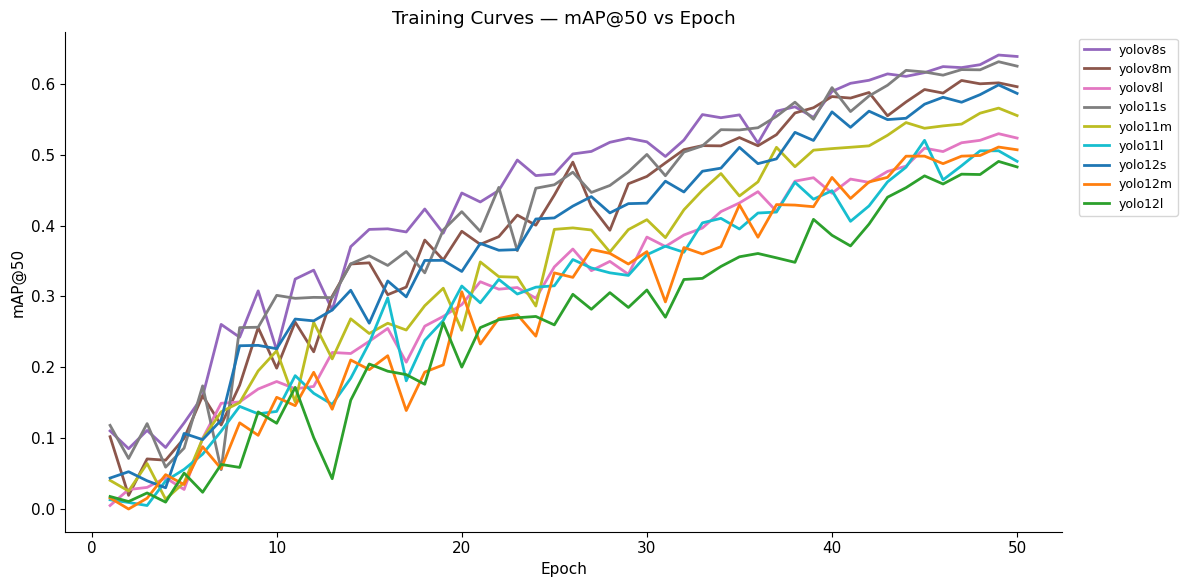

Saved: training_curves.png

✅ All plots saved!


In [ ]:
# ── 5. Training curves from wandb ─────────────────────────────
import wandb

api = wandb.Api()
runs = api.runs("namishemail-george-mason-university/april-detection")

fig, ax = plt.subplots(figsize=(12, 6))
plotted = 0
for i, run in enumerate(runs):
    if run.state != "finished":
        continue
    try:
        hist = run.history(keys=["epoch", "mAP50"], samples=100)
        if "mAP50" not in hist.columns or hist["mAP50"].isna().all():
            continue
        hist_clean = hist.dropna(subset=["mAP50"])
        ax.plot(hist_clean["epoch"], hist_clean["mAP50"],
                label=run.name, color=COLORS[i % len(COLORS)], linewidth=2)
        plotted += 1
    except:
        continue

if plotted > 0:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP@50")
    ax.set_title("Training Curves — mAP@50 vs Epoch")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: training_curves.png")
else:
    print("⚠️ No training curve data found in wandb")

print("\n✅ All plots saved!")